In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('/content/covid_19_clean_complete.csv')

In [6]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [8]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [9]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

,0
Province/State,70.114943
Country/Region,0.000000
Lat,0.000000
Long,0.000000
Date,0.000000
Confirmed,0.000000
Deaths,0.000000
Recovered,0.000000
Active,0.000000
WHO Region,0.000000


In [11]:
df['Province/State'] = df['Province/State'].fillna('Unknown')

In [12]:
df['Province/State']

,Province/State
0,Unknown
1,Unknown
2,Unknown
3,Unknown
4,Unknown
...,...
49063,Unknown
49064,Unknown
49065,Unknown
49066,Unknown


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Date'].dtype

dtype('O')

In [15]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].dtype

dtype('<M8[ns]')

In [16]:
df[df['Active'] < 0]

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
16238,Hainan,China,19.195900,109.745300,2020-03-24,168,6,168,-6,Western Pacific
16499,Hainan,China,19.195900,109.745300,2020-03-25,168,6,168,-6,Western Pacific
16760,Hainan,China,19.195900,109.745300,2020-03-26,168,6,168,-6,Western Pacific
17021,Hainan,China,19.195900,109.745300,2020-03-27,168,6,168,-6,Western Pacific
17282,Hainan,China,19.195900,109.745300,2020-03-28,168,6,168,-6,Western Pacific
17543,Hainan,China,19.195900,109.745300,2020-03-29,168,6,168,-6,Western Pacific
17804,Hainan,China,19.195900,109.745300,2020-03-30,168,6,168,-6,Western Pacific
18065,Hainan,China,19.195900,109.745300,2020-03-31,168,6,168,-6,Western Pacific
18326,Hainan,China,19.195900,109.745300,2020-04-01,168,6,168,-6,Western Pacific
32059,Channel Islands,United Kingdom,49.372300,-2.364400,2020-05-23,558,45,515,-2,Europe


In [18]:
df['Active'] = df['Confirmed'] - df['Deaths'] - df['Recovered']

In [19]:
df.loc[df['Active'] < 0, 'Active'] = 0

In [21]:
df.isnull().sum()

,0
Province/State,0
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df['Active'].min()

0

In [25]:
total_confirmed = df['Confirmed'].sum()
total_confirmed

np.int64(828508482)

In [26]:
total_deaths = df['Deaths'].sum()
total_deaths

np.int64(43384903)

In [27]:
total_recovered = df['Recovered'].sum()
total_recovered

np.int64(388408229)

In [28]:
death_rate = (43384903 / 828508482) * 100
recovery_rate = (388408229 / 828508482) * 100

print("Death Rate:", death_rate, "%")
print("Recovery Rate:", recovery_rate, "%")

Death Rate: 5.23650680018023 %
Recovery Rate: 46.88041672939686 %


In [29]:
latest_date = df['Date'].max()

latest_df = df[df['Date'] == latest_date]

country_totals = latest_df.groupby('Country/Region')[
    ['Confirmed', 'Deaths', 'Recovered', 'Active']
].sum().reset_index()

top_10_confirmed = country_totals.sort_values(
    by='Confirmed', ascending=False
).head(10)

top_10_confirmed

,Country/Region,Confirmed,Deaths,Recovered,Active
173,US,4290259,148011,1325804,2816444
23,Brazil,2442375,87618,1846641,508116
79,India,1480073,33408,951166,495499
138,Russia,816680,13334,602249,201097
154,South Africa,452529,7067,274925,170537
111,Mexico,395489,44022,303810,47657
132,Peru,389717,18418,272547,98752
35,Chile,347923,9187,319954,18782
177,United Kingdom,301708,45844,1437,254427
81,Iran,293606,15912,255144,22550


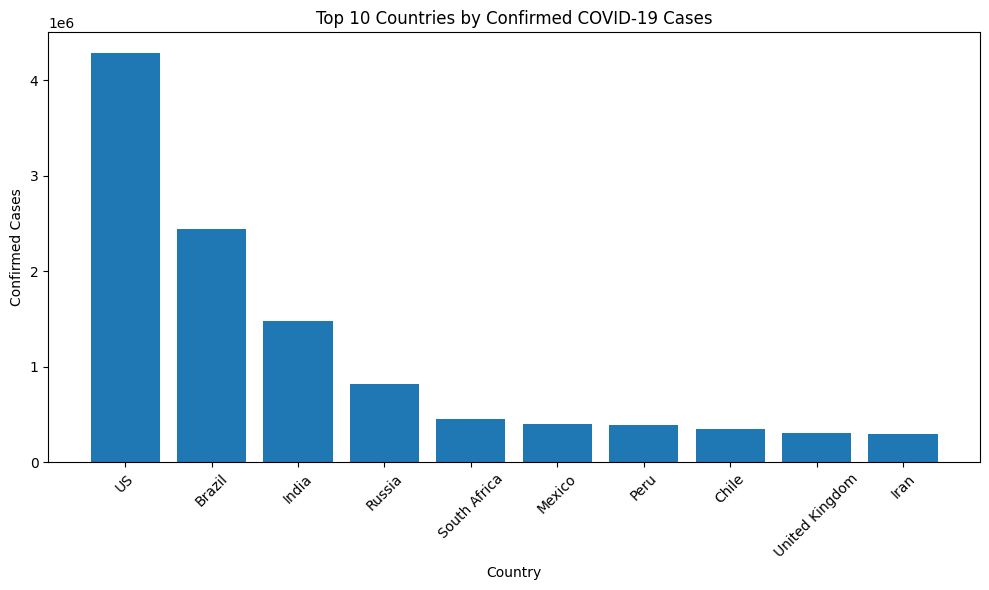

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_10_confirmed['Country/Region'],
    top_10_confirmed['Confirmed']
)

plt.title('Top 10 Countries by Confirmed COVID-19 Cases')
plt.xlabel('Country')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [31]:
top_10_deaths = country_totals.sort_values(
    by='Deaths', ascending=False
).head(10)

top_10_deaths

,Country/Region,Confirmed,Deaths,Recovered,Active
173,US,4290259,148011,1325804,2816444
23,Brazil,2442375,87618,1846641,508116
177,United Kingdom,301708,45844,1437,254427
111,Mexico,395489,44022,303810,47657
85,Italy,246286,35112,198593,12581
79,India,1480073,33408,951166,495499
61,France,220352,30212,81212,108928
157,Spain,272421,28432,150376,93613
132,Peru,389717,18418,272547,98752
81,Iran,293606,15912,255144,22550


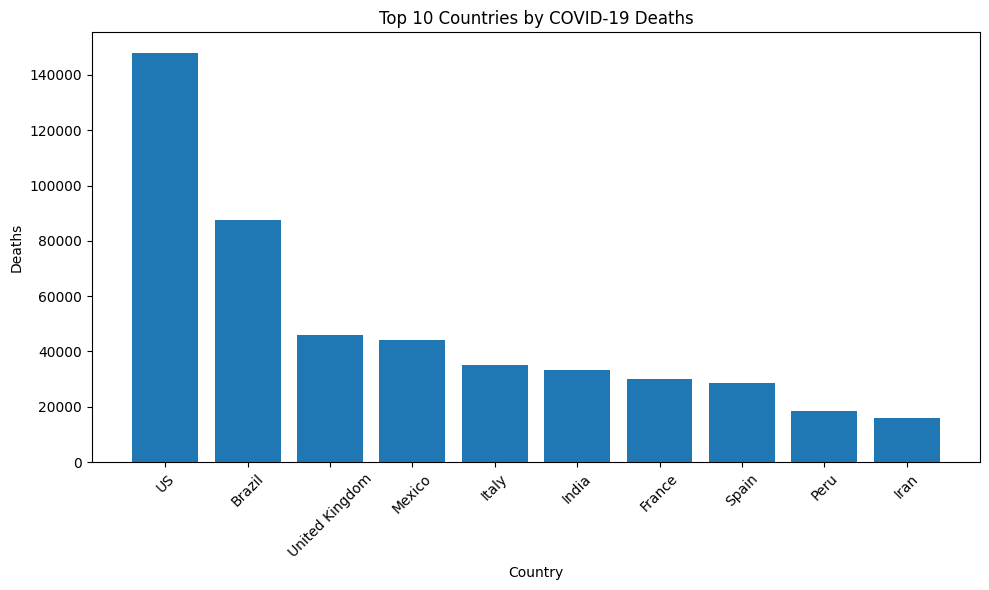

In [32]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_10_deaths['Country/Region'],
    top_10_deaths['Deaths']
)

plt.title('Top 10 Countries by COVID-19 Deaths')
plt.xlabel('Country')
plt.ylabel('Deaths')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [33]:
country_totals['Recovery Rate'] = (
    country_totals['Recovered'] / country_totals['Confirmed']
) * 100

In [34]:
top_10_recovery = country_totals.sort_values(
    by='Recovery Rate', ascending=False
).head(10)

top_10_recovery

,Country/Region,Confirmed,Deaths,Recovered,Active,Recovery Rate
49,Dominica,18,0,18,0,100.000000
75,Holy See,12,0,12,0,100.000000
69,Grenada,23,0,23,0,100.000000
48,Djibouti,5059,58,4977,24,98.379126
78,Iceland,1854,10,1823,21,98.327940
24,Brunei,141,3,138,0,97.872340
121,New Zealand,1557,22,1514,21,97.238279
136,Qatar,109597,165,106328,3104,97.017254
105,Malaysia,8904,124,8601,179,96.597035
110,Mauritius,344,10,332,2,96.511628


In [35]:
global_daily = df.groupby('Date')[[
    'Confirmed', 'Deaths', 'Recovered'
]].sum().reset_index()

global_daily.head()

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,555,17,28
1,2020-01-23,654,18,30
2,2020-01-24,941,26,36
3,2020-01-25,1434,42,39
4,2020-01-26,2118,56,52


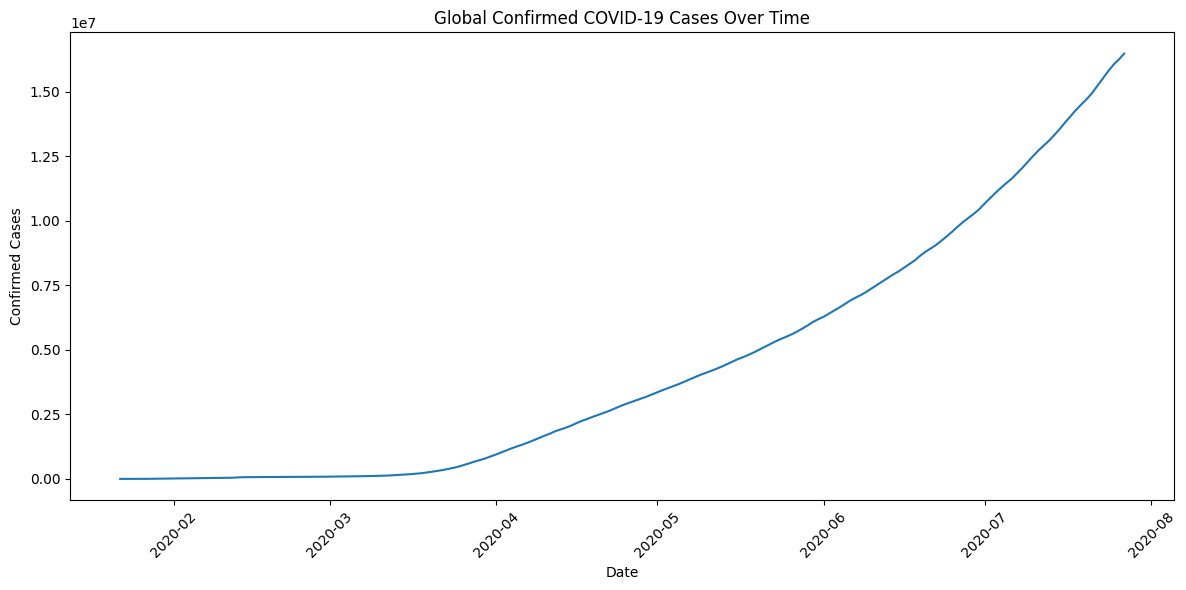

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(
    global_daily['Date'],
    global_daily['Confirmed']
)

plt.title('Global Confirmed COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [37]:
global_daily['New Cases'] = global_daily['Confirmed'].diff()

In [38]:
largest_increases = global_daily.sort_values(
    by='New Cases', ascending=False
).head(10)

largest_increases[['Date', 'New Cases']]

,Date,New Cases
183,2020-07-23,282756.0
184,2020-07-24,281164.0
182,2020-07-22,280647.0
185,2020-07-25,255545.0
176,2020-07-16,252541.0
177,2020-07-17,242038.0
178,2020-07-18,237635.0
181,2020-07-21,233455.0
170,2020-07-10,232577.0
175,2020-07-15,231117.0


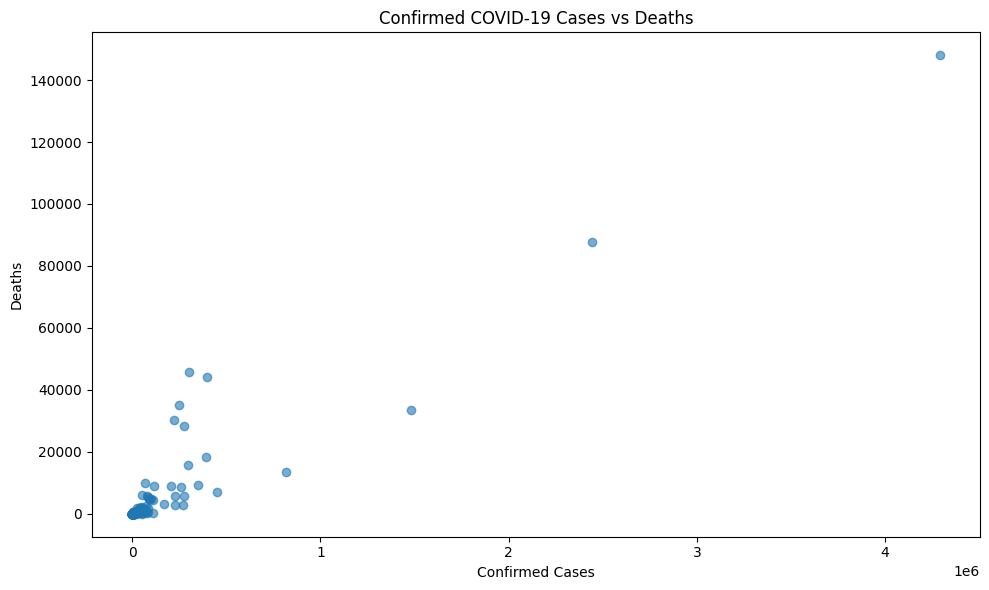

In [39]:
plt.figure(figsize=(10, 6))

plt.scatter(
    country_totals['Confirmed'],
    country_totals['Deaths'],
    alpha=0.6
)

plt.title('Confirmed COVID-19 Cases vs Deaths')
plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')

plt.tight_layout()
plt.show()

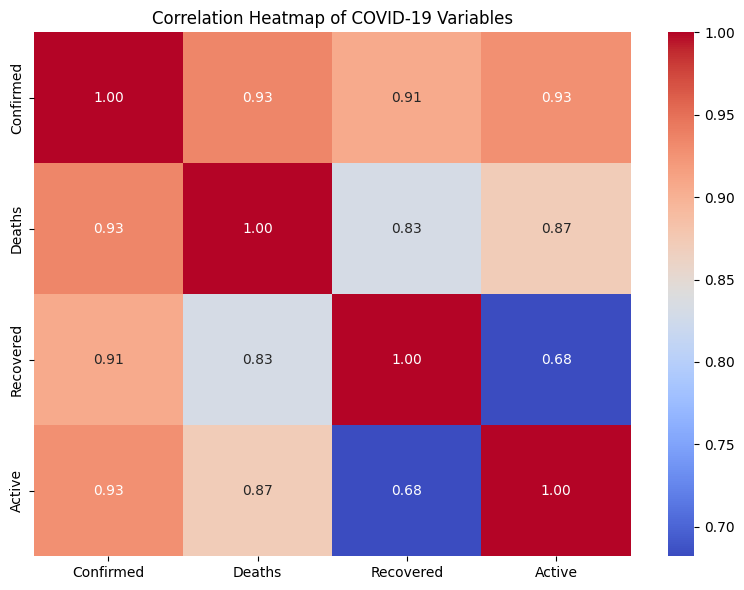

In [40]:
correlation = country_totals[
    ['Confirmed', 'Deaths', 'Recovered', 'Active']
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of COVID-19 Variables')
plt.tight_layout()

plt.show()

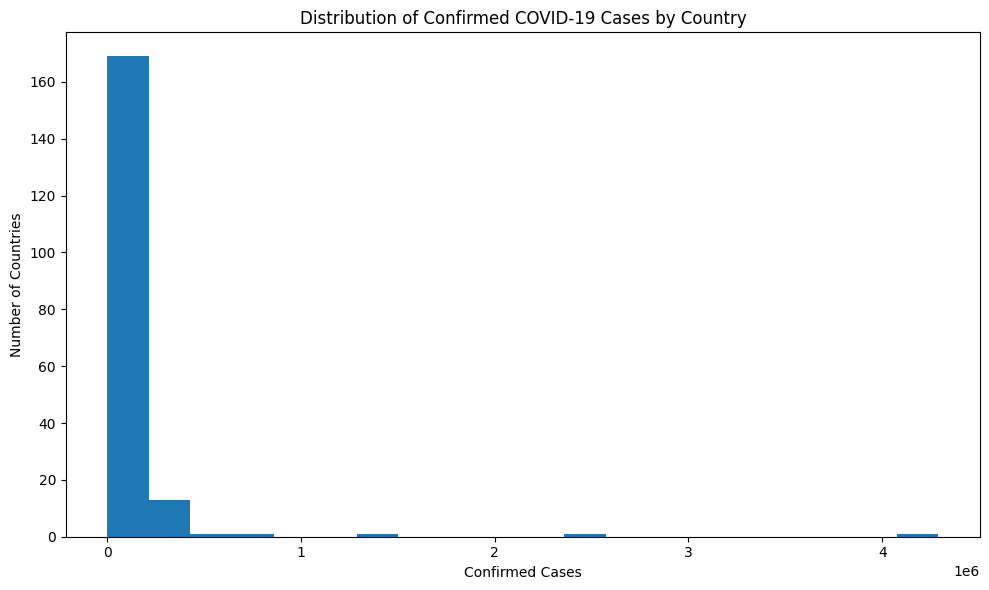

In [41]:
plt.figure(figsize=(10, 6))

plt.hist(
    country_totals['Confirmed'],
    bins=20
)

plt.title('Distribution of Confirmed COVID-19 Cases by Country')
plt.xlabel('Confirmed Cases')
plt.ylabel('Number of Countries')

plt.tight_layout()
plt.show()

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

country_totals[
    ['Confirmed_Scaled', 'Deaths_Scaled', 'Recovery_Scaled']
] = scaler.fit_transform(
    country_totals[
        ['Confirmed', 'Deaths', 'Recovery Rate']
    ]
)

country_totals.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,Recovery Rate,Confirmed_Scaled,Deaths_Scaled,Recovery_Scaled
0,Afghanistan,36263,1269,25198,9796,69.486805,0.008450,0.008574,0.694868
1,Albania,4880,144,2745,1991,56.250000,0.001135,0.000973,0.562500
2,Algeria,27973,1163,18837,7973,67.339935,0.006518,0.007858,0.673399
3,Andorra,907,52,803,52,88.533627,0.000209,0.000351,0.885336
4,Angola,950,41,242,667,25.473684,0.000219,0.000277,0.254737


In [43]:
country_totals['COVID Impact Score'] = (
    0.4 * country_totals['Confirmed_Scaled']
    + 0.4 * country_totals['Deaths_Scaled']
    + 0.2 * (1 - country_totals['Recovery_Scaled'])
)

In [44]:
impact_ranking = country_totals.sort_values(
    by='COVID Impact Score',
    ascending=False
)

impact_ranking[
    ['Country/Region', 'Confirmed', 'Deaths',
     'Recovery Rate', 'COVID Impact Score']
].head(10)

,Country/Region,Confirmed,Deaths,Recovery Rate,COVID Impact Score
173,US,4290259,148011,30.902656,0.938195
23,Brazil,2442375,87618,75.608414,0.513284
177,United Kingdom,301708,45844,0.476288,0.351070
79,India,1480073,33408,64.264803,0.299749
32,Canada,116458,8944,0.000000,0.235028
61,France,220352,30212,36.855577,0.228480
161,Sweden,79395,5700,0.000000,0.222806
120,Netherlands,53413,6160,0.353846,0.220919
147,Serbia,24141,543,0.000000,0.203717
111,Mexico,395489,44022,76.818824,0.202204


In [46]:
def classify_impact(score):
    if score < 0.20:
        return 'Low'
    elif score < 0.50:
        return 'Medium'
    else:
        return 'High'

country_totals['Impact Level'] = (
    country_totals['COVID Impact Score'].apply(classify_impact)
)

In [47]:
impact_counts = country_totals['Impact Level'].value_counts()

impact_counts

,count
Impact Level,
Low,174
Medium,11
High,2


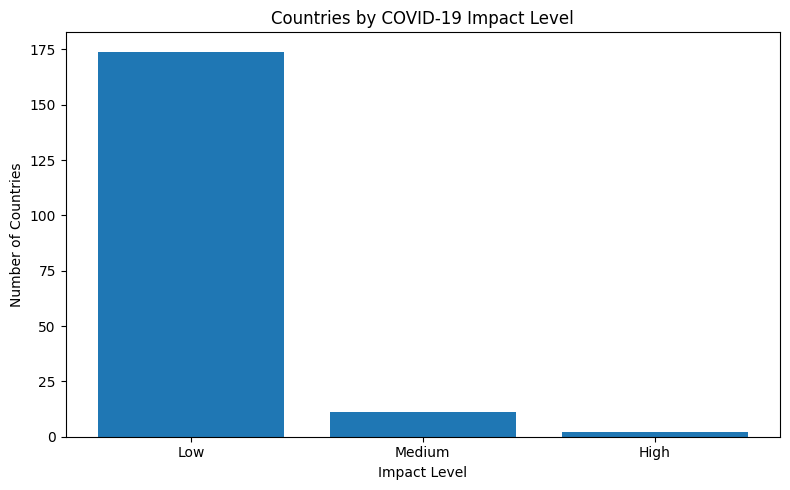

In [48]:
plt.figure(figsize=(8, 5))

plt.bar(
    impact_counts.index,
    impact_counts.values
)

plt.title('Countries by COVID-19 Impact Level')
plt.xlabel('Impact Level')
plt.ylabel('Number of Countries')

plt.tight_layout()
plt.show()

In [49]:
ml_df = df.copy()

ml_df = ml_df.sort_values('Date')

ml_df[['Date', 'Confirmed', 'Deaths', 'Recovered', 'Active']].head()

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
166,2020-01-22,0,0,0,0
167,2020-01-22,0,0,0,0
168,2020-01-22,0,0,0,0
169,2020-01-22,0,0,0,0


In [50]:
ml_df['New Cases'] = (
    ml_df.groupby('Country/Region')['Confirmed']
    .diff()
)

ml_df[['Date', 'Country/Region', 'Confirmed', 'New Cases']].head(10)

,Date,Country/Region,Confirmed,New Cases
0,2020-01-22,Afghanistan,0,NaN
166,2020-01-22,Netherlands,0,NaN
167,2020-01-22,Netherlands,0,0.0
168,2020-01-22,New Zealand,0,NaN
169,2020-01-22,Nicaragua,0,NaN
170,2020-01-22,Niger,0,NaN
171,2020-01-22,Nigeria,0,NaN
172,2020-01-22,North Macedonia,0,NaN
173,2020-01-22,Norway,0,NaN
174,2020-01-22,Oman,0,NaN


In [51]:
ml_df['New Cases Lag 1'] = (
    ml_df.groupby('Country/Region')['New Cases'].shift(1)
)

ml_df['New Cases Lag 7'] = (
    ml_df.groupby('Country/Region')['New Cases'].shift(7)
)

ml_df['Rolling 7 Days'] = (
    ml_df.groupby('Country/Region')['New Cases']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

ml_df[['Date', 'Country/Region', 'New Cases',
       'New Cases Lag 1', 'New Cases Lag 7',
       'Rolling 7 Days']].head(15)

,Date,Country/Region,New Cases,New Cases Lag 1,New Cases Lag 7,Rolling 7 Days
0,2020-01-22,Afghanistan,NaN,NaN,NaN,NaN
166,2020-01-22,Netherlands,NaN,NaN,NaN,NaN
167,2020-01-22,Netherlands,0.0,NaN,NaN,NaN
168,2020-01-22,New Zealand,NaN,NaN,NaN,NaN
169,2020-01-22,Nicaragua,NaN,NaN,NaN,NaN
170,2020-01-22,Niger,NaN,NaN,NaN,NaN
171,2020-01-22,Nigeria,NaN,NaN,NaN,NaN
172,2020-01-22,North Macedonia,NaN,NaN,NaN,NaN
173,2020-01-22,Norway,NaN,NaN,NaN,NaN
174,2020-01-22,Oman,NaN,NaN,NaN,NaN


In [52]:
ml_df = ml_df.groupby(
    ['Date', 'Country/Region'],
    as_index=False
)[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum()

ml_df = ml_df.sort_values(['Country/Region', 'Date'])

ml_df.head(10)

,Date,Country/Region,Confirmed,Deaths,Recovered,Active
0,2020-01-22,Afghanistan,0,0,0,0
187,2020-01-23,Afghanistan,0,0,0,0
374,2020-01-24,Afghanistan,0,0,0,0
561,2020-01-25,Afghanistan,0,0,0,0
748,2020-01-26,Afghanistan,0,0,0,0
935,2020-01-27,Afghanistan,0,0,0,0
1122,2020-01-28,Afghanistan,0,0,0,0
1309,2020-01-29,Afghanistan,0,0,0,0
1496,2020-01-30,Afghanistan,0,0,0,0
1683,2020-01-31,Afghanistan,0,0,0,0


In [53]:
ml_df['New Cases'] = (
    ml_df.groupby('Country/Region')['Confirmed']
    .diff()
)

ml_df[['Date', 'Country/Region', 'Confirmed', 'New Cases']].head(15)

,Date,Country/Region,Confirmed,New Cases
0,2020-01-22,Afghanistan,0,NaN
187,2020-01-23,Afghanistan,0,0.0
374,2020-01-24,Afghanistan,0,0.0
561,2020-01-25,Afghanistan,0,0.0
748,2020-01-26,Afghanistan,0,0.0
935,2020-01-27,Afghanistan,0,0.0
1122,2020-01-28,Afghanistan,0,0.0
1309,2020-01-29,Afghanistan,0,0.0
1496,2020-01-30,Afghanistan,0,0.0
1683,2020-01-31,Afghanistan,0,0.0


In [54]:
ml_df['New Cases Lag 1'] = (
    ml_df.groupby('Country/Region')['New Cases'].shift(1)
)

ml_df['New Cases Lag 7'] = (
    ml_df.groupby('Country/Region')['New Cases'].shift(7)
)

ml_df['Rolling 7 Days'] = (
    ml_df.groupby('Country/Region')['New Cases']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

ml_df[['Date', 'Country/Region', 'New Cases',
       'New Cases Lag 1', 'New Cases Lag 7',
       'Rolling 7 Days']].tail(10)

,Date,Country/Region,New Cases,New Cases Lag 1,New Cases Lag 7,Rolling 7 Days
33472,2020-07-18,Zimbabwe,58.0,58.0,40.0,68.285714
33659,2020-07-19,Zimbabwe,133.0,58.0,3.0,70.857143
33846,2020-07-20,Zimbabwe,102.0,133.0,49.0,89.428571
34033,2020-07-21,Zimbabwe,107.0,102.0,30.0,97.000000
34220,2020-07-22,Zimbabwe,214.0,107.0,25.0,108.000000
34407,2020-07-23,Zimbabwe,90.0,214.0,273.0,135.000000
34594,2020-07-24,Zimbabwe,172.0,90.0,58.0,108.857143
34781,2020-07-25,Zimbabwe,138.0,172.0,58.0,125.142857
34968,2020-07-26,Zimbabwe,78.0,138.0,133.0,136.571429
35155,2020-07-27,Zimbabwe,192.0,78.0,102.0,128.714286


In [55]:
features = [
    'New Cases Lag 1',
    'New Cases Lag 7',
    'Rolling 7 Days'
]

X = ml_df[features]
y = ml_df['New Cases']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (35156, 3)
y shape: (35156,)


In [56]:
ml_df = ml_df.dropna(subset=features + ['New Cases'])

print("New shape:", ml_df.shape)
print("Missing values:")
print(ml_df[features + ['New Cases']].isnull().sum())

New shape: (33660, 10)
Missing values:
New Cases Lag 1    0
New Cases Lag 7    0
Rolling 7 Days     0
New Cases          0
dtype: int64


In [57]:
split_index = int(len(ml_df) * 0.8)

train = ml_df.iloc[:split_index]
test = ml_df.iloc[split_index:]

X_train = train[features]
y_train = train['New Cases']

X_test = test[features]
y_test = test['New Cases']

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Train last date:", train['Date'].max())
print("Test first date:", test['Date'].min())

Training data: (26928, 3)
Testing data: (6732, 3)
Train last date: 2020-07-27 00:00:00
Test first date: 2020-01-30 00:00:00


In [58]:
ml_df = ml_df.sort_values(['Date', 'Country/Region']).reset_index(drop=True)

split_index = int(len(ml_df) * 0.8)

train = ml_df.iloc[:split_index]
test = ml_df.iloc[split_index:]

X_train = train[features]
y_train = train['New Cases']

X_test = test[features]
y_test = test['New Cases']

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Train last date:", train['Date'].max())
print("Test first date:", test['Date'].min())

Training data: (26928, 3)
Testing data: (6732, 3)
Train last date: 2020-06-21 00:00:00
Test first date: 2020-06-22 00:00:00


In [60]:
from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 185.84427723545622
RMSE: 948.0158304184525
R² Score: 0.9715168372768428


In [63]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [64]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
MAE: 317.87596558868364
RMSE: 2215.0490796505887
R² Score: 0.8445023825726371


In [65]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)

In [66]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R² Score:", r2_gb)

Gradient Boosting Results
MAE: 309.0856020118959
RMSE: 2125.8713052003222
R² Score: 0.856770996001425


In [67]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_lr
})

comparison.head(20)

,Actual,Predicted
0,324.0,577.966357
1,33.0,78.791874
2,149.0,139.887904
3,0.0,9.909912
4,3.0,15.587586
5,0.0,9.782325
6,2146.0,1568.806541
7,320.0,532.238411
8,18.0,26.006350
9,39.0,36.660019


In [69]:
comparison['Error'] = (
    comparison['Actual'] - comparison['Predicted']
)

comparison['Absolute Error'] = (
    comparison['Error'].abs()
)

comparison.head(20)

,Actual,Predicted,Error,Absolute Error
0,324.0,577.966357,-253.966357,253.966357
1,33.0,78.791874,-45.791874,45.791874
2,149.0,139.887904,9.112096,9.112096
3,0.0,9.909912,-9.909912,9.909912
4,3.0,15.587586,-12.587586,12.587586
5,0.0,9.782325,-9.782325,9.782325
6,2146.0,1568.806541,577.193459,577.193459
7,320.0,532.238411,-212.238411,212.238411
8,18.0,26.006350,-8.006350,8.006350
9,39.0,36.660019,2.339981,2.339981


In [70]:
print("Actual mean:", y_test.mean())
print("Actual median:", y_test.median())
print("Predicted mean:", y_pred_lr.mean())
print("Predicted median:", np.median(y_pred_lr))

Actual mean: 1121.0056446821152
Actual median: 39.0
Predicted mean: 1107.8754004854613
Predicted median: 56.28911786587209


In [71]:
error_percentage = (mae / y_test.mean()) * 100

print("MAE as % of actual mean:", error_percentage)

MAE as % of actual mean: 16.578353384487755


In [72]:
print("Maximum actual cases:", y_test.max())
print("Maximum prediction:", y_pred_lr.max())

Maximum actual cases: 77255.0
Maximum prediction: 72576.6198173256


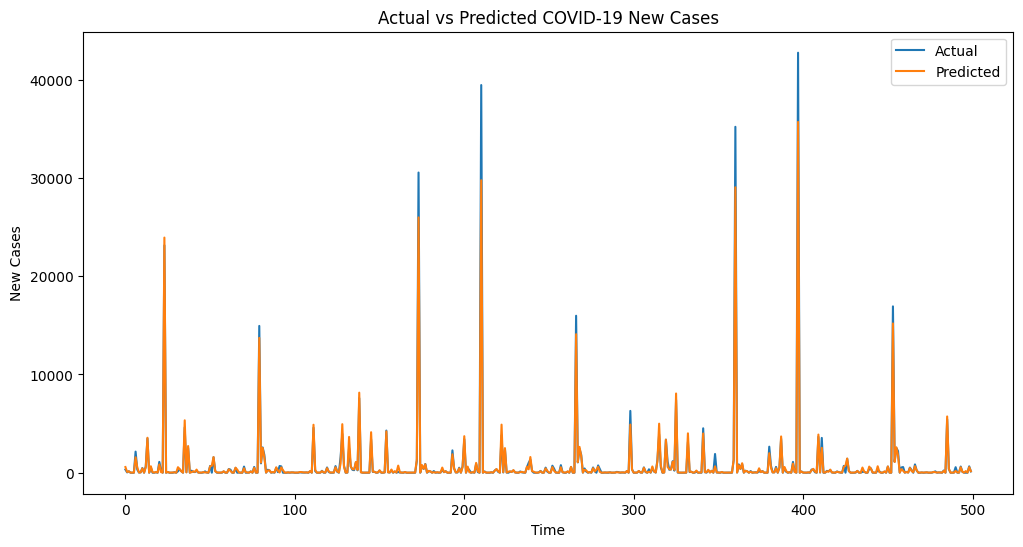

In [73]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values[:500], label='Actual')
plt.plot(y_pred_lr[:500], label='Predicted')

plt.title('Actual vs Predicted COVID-19 New Cases')
plt.xlabel('Time')
plt.ylabel('New Cases')
plt.legend()
plt.show()

In [74]:
import joblib

joblib.dump(model_lr, 'covid_linear_regression_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [75]:
y_train_pred = model_lr.predict(X_train)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred_lr)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 0.9401508043022135
Test R²: 0.9715168372768428


In [76]:
from google.colab import files

files.download('covid_linear_regression_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>